In [93]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve
from scipy.optimize import shgo
from scipy import interpolate

In [94]:
SIMPACK_WheelCurvature = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/WheelCurvature.txt', delimiter = ',')
SIMPACK_WheelGradient = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/WheelGradient.txt', delimiter = ',')
SIMPACK_WheelProfile = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/WheelProfile.txt', delimiter = ',')
SIMPACK_RailCurvature = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/RailCurvature.txt', delimiter = ',')
SIMPACK_RailGradient = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/RailGradient.txt', delimiter = ',')
SIMPACK_RailProfile = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/RailProfile.txt', delimiter = ',')
SIMPACK_ContactOverview = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults/ContactOverview_Right.txt', delimiter = ',')

In [95]:
RatiosSIMPACK = np.loadtxt("RationNormalSIMPACK.txt", delimiter = ",")

In [96]:
E = 210e9
nu = 0.28
Estar = 1/((1+nu**2)/E*2)

b0 = 0.75
gauge = 1.435
Rail_Inclination = 20
Rail_cant = -np.arctan(1/Rail_Inclination)

In [97]:
if Rail_Inclination == 40:
    SIMPACK_ContactArea = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/ContactArea.txt', delimiter = ',')
    SIMPACK_ContactLateralPosWheel = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/ContactLateralPosWheel.txt', delimiter = ',')
    SIMPACK_ContactLateralPosRail = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/ContactLateralPosRail.txt', delimiter = ',')
    SIMPACK_EquivalentPenetration = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/EquivalentPenetration.txt', delimiter = ',')
    SIMPACK_PatchLength = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/PatchLength.txt', delimiter = ',')
    SIMPACK_PatchWidth = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/PatchWidth.txt', delimiter = ',')
    SIMPACK_SemiAxisRatio = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/SemiAxisRatio.txt', delimiter = ',')
    SIMPACK_ContactVerticalPosWheel = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/ContactVerticalPosWheel.txt', delimiter = ',')
    SIMPACK_WheelRise = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/WheelRise.txt', delimiter = ',')
    SIMPACK_NormalForce = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/NormalForce.txt', delimiter = ',')
    SIMPACK_PatchStart = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/PatchStartPos.txt', delimiter = ',')
    SIMPACK_PatchEnd = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/PatchEndPos.txt', delimiter = ',')
    SIMPACK_SituationOverview = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/SituationOverview.txt', delimiter = ',')
    SIMPACK_Number_of_Patches = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_40/Number_of_Patches.txt', delimiter = ',')
elif Rail_Inclination == 20:
    SIMPACK_ContactArea = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/ContactArea.txt', delimiter = ',')
    SIMPACK_ContactLateralPosWheel = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/ContactLateralPosWheel.txt', delimiter = ',')
    SIMPACK_ContactLateralPosRail = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/ContactLateralPosRail.txt', delimiter = ',')
    SIMPACK_EquivalentPenetration = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/EquivalentPenetration.txt', delimiter = ',')
    SIMPACK_PatchLength = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/PatchLength.txt', delimiter = ',')
    SIMPACK_PatchWidth = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/PatchWidth.txt', delimiter = ',')
    SIMPACK_SemiAxisRatio = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/SemiAxisRatio.txt', delimiter = ',')
    SIMPACK_ContactVerticalPosWheel = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/ContactVerticalPosWheel.txt', delimiter = ',')
    SIMPACK_WheelRise = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/WheelRise.txt', delimiter = ',')
    SIMPACK_NormalForce = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/NormalForce.txt', delimiter = ',')
    SIMPACK_PatchStart = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/PatchStartPos.txt', delimiter = ',')
    SIMPACK_PatchEnd = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/PatchEndPos.txt', delimiter = ',')
    SIMPACK_SituationOverview = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/SituationOverview.txt', delimiter = ',')
    SIMPACK_Number_of_Patches = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_20/Number_of_Patches.txt', delimiter = ',')
elif Rail_Inclination == 30:
    SIMPACK_ContactArea = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/ContactArea.txt', delimiter = ',')
    SIMPACK_ContactLateralPosWheel = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/ContactLateralPosWheel.txt', delimiter = ',')
    SIMPACK_ContactLateralPosRail = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/ContactLateralPosRail.txt', delimiter = ',')
    SIMPACK_EquivalentPenetration = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/EquivalentPenetration.txt', delimiter = ',')
    SIMPACK_PatchLength = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/PatchLength.txt', delimiter = ',')
    SIMPACK_PatchWidth = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/PatchWidth.txt', delimiter = ',')
    SIMPACK_SemiAxisRatio = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/SemiAxisRatio.txt', delimiter = ',')
    SIMPACK_ContactVerticalPosWheel = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/ContactVerticalPosWheel.txt', delimiter = ',')
    SIMPACK_WheelRise = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/WheelRise.txt', delimiter = ',')
    SIMPACK_NormalForce = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/NormalForce.txt', delimiter = ',')
    SIMPACK_PatchStart = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/PatchStartPos.txt', delimiter = ',')
    SIMPACK_PatchEnd = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/PatchEndPos.txt', delimiter = ',')
    SIMPACK_SituationOverview = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/SituationOverview.txt', delimiter = ',')
    SIMPACK_Number_of_Patches = np.loadtxt('D:\From_Nier\Railway\PPP\prove\Wheel_Rail_Profiles\AllWheel\CleanedResults_30/Number_of_Patches.txt', delimiter = ',')


In [98]:
DeltaX = 0.025

NumRail = np.arange(0,500-DeltaX,DeltaX)
NumRailOld = np.arange(500)
yRail = interpolate.PchipInterpolator(NumRailOld, SIMPACK_RailProfile[:,0])(NumRail)
zRail = interpolate.PchipInterpolator(SIMPACK_RailProfile[:,0], SIMPACK_RailProfile[:,1])(yRail)

UIC60 = np.zeros([len(zRail),2])
UIC60[:,0] = yRail
UIC60[:,1] = -zRail

NumWheel = np.arange(0,500-DeltaX,DeltaX)
NumWheelOld = np.arange(500)
yWheel = interpolate.PchipInterpolator(NumWheelOld, SIMPACK_ContactOverview[:,0]-b0)(NumWheel)
zWheel = interpolate.PchipInterpolator(SIMPACK_ContactOverview[:,0]-b0, SIMPACK_ContactOverview[:,1]-0.01)(yWheel)

S1002 = np.zeros([len(zWheel),2])
S1002[:,0] = yWheel
S1002[:,1] = -zWheel

In [99]:
RZ = np.array([[np.cos(Rail_cant), -np.sin(Rail_cant), 0],
               [np.sin(Rail_cant), np.cos(Rail_cant), 0],
               [0, 0, 1]])

RailTilted = np.zeros([len(UIC60),2])

for jj in range(0,len(UIC60)):
    Coord = np.array([UIC60[jj,0], UIC60[jj,1], 0])
    RailTiltLocal = np.matmul(RZ,np.transpose(Coord))
    RailTilted[jj,0] = RailTiltLocal[0]
    RailTilted[jj,1] = RailTiltLocal[1]

GaugeCorner = np.where(RailTilted[:,1]<=0.014)[0]

In [100]:
RailDistance = -RailTilted[GaugeCorner[0],0]+gauge/2
RailTiltedPositioned = RailTilted
RailTiltedPositioned[:,0] = RailTilted[:,0]-RailTilted[GaugeCorner[0],0]+gauge/2
WheelPositioned = np.zeros([len(S1002),2])
WheelPositioned[:,1] = S1002[:,1]
WheelPositioned[:,0] = S1002[:,0]+b0

Indexes = np.where(S1002[:,0]>=0)
Radius = np.zeros([len(S1002),2])
Radius[:,0] = S1002[:,0]+b0
Radius[:,1] = 0.46+S1002[:,1]-S1002[Indexes[0][0],1]

WheelAngle = np.arctan((S1002[0:-1,1] - S1002[1:,1])/(S1002[0:-1,0] - S1002[1:,0]))
WheelAngle = np.append(WheelAngle, 0)
RailAngle = np.arctan((RailTilted[0:-1,1] - RailTilted[1:,1])/(RailTilted[0:-1,0] - RailTilted[1:,0]))
RailAngle = np.append(RailAngle, 0)

In [101]:
YawAngle3 = 3*np.pi/180
YawAngle6 = 6*np.pi/180

WheelPositionedYawed3 = np.zeros([len(S1002),2])
WheelPositionedYawed3[:,0] = S1002[:,0]*np.cos(YawAngle3)-Radius[:,1]*np.tan(WheelAngle)*(np.sin(YawAngle3))**2/np.cos(YawAngle3)+b0
P = 1-(1+(np.tan(WheelAngle))**2)*(np.sin(YawAngle3))**2
WheelPositionedYawed3[:,1] = Radius[:,1]*np.sqrt(P)/np.cos(YawAngle3)-0.46

WheelPositionedYawed6 = np.zeros([len(S1002),2])
WheelPositionedYawed6[:,0] = S1002[:,0]*np.cos(YawAngle6)-Radius[:,1]*np.tan(WheelAngle)*(np.sin(YawAngle6))**2/np.cos(YawAngle6)+b0
P = 1-(1+(np.tan(WheelAngle))**2)*(np.sin(YawAngle6))**2
WheelPositionedYawed6[:,1] = Radius[:,1]*np.sqrt(P)/np.cos(YawAngle6)-0.46

In [102]:
class datawheel:
    def __init__(self, Dy = 0, Appr = 0, NF = 0, WA = 0, QA = 0, DZ = 0, Cent = 0,DyWheel = 0, DzWheel = 0,
                 aH = 0, bH = 0, AHertz = 0, BHertz = 0, rWy = 0, rWx = 0, rRy = 0,
                 ratioHertz = 0, tetaHertz = 0, DyRail = 0, DzRail = 0, StartPos = 0, EndPos = 0, Radius = 0):
        self.DyWheeslet = Dy
        self.approach = Appr
        self.NormalForce = NF
        self.WheelAngle = WA
        self.QForce = QA
        self.Deltaz = DZ
        self.centroid = Cent
        self.DyWheel = DyWheel
        self.DzWheel = DzWheel
        self.a = aH
        self.b = bH
        self.AHertz = AHertz
        self.BHertz = BHertz
        self.rWy = rWy
        self.rWx = rWx
        self.rRy = rRy
        self.tetaHertz = tetaHertz
        self.ratioHertz = ratioHertz
        self.DyRail = DyRail
        self.DzRail = DzRail
        self.StartPos = StartPos
        self.EndPos = EndPos
        self.Radius = Radius

    def reset_zeros(self):
        self.DyWheeslet = 0
        self.approach = 0
        self.NormalForce = 0
        self.WheelAngle = 0
        self.QForce = 0
        self.Deltaz = 0
        self.centroid = 0
        self.DyWheel = 0
        self.DzWheel = 0
        self.a = 0
        self.b = 0
        self.AHertz = 0
        self.BHertz = 0
        self.rWy = 0
        self.rWx = 0
        self.rRy = 0
        self.tetaHertz = 0
        self.ratioHertz = 0
        self.DyRail = 0
        self.DzRail = 0
        self.StartPos = 0
        self.EndPos = 0
        self.Radius = 0

Search1 = datawheel()
Search2 = datawheel()
Search3 = datawheel()

In [103]:
def findAlpha(alpha, Area, Width):
    Res = Area-0.5*Width**2/4*(alpha-np.sin(alpha))/(np.sin(alpha/2)**2)
    return Res

In [104]:
def PatchSearch(ContactPos, WheelInt, Rail, radius, SearchPath, deltaz, discretization):
    
    ContactRotationAngle = -(np.arctan((Rail[ContactPos[-1],1]-Rail[ContactPos[0],1])/
                                       (Rail[ContactPos[-1],0]-Rail[ContactPos[0],0])))
        
    WheelCoor = np.vstack((np.reshape(Rail[ContactPos,0],[1,len(ContactPos)])-Rail[ContactPos[0],0],
                            np.reshape(WheelInt[ContactPos],[1,len(ContactPos)])-WheelInt[ContactPos[0]],
                            np.zeros([1,len(ContactPos)])))
    RadiusCoor = np.vstack((np.reshape(Rail[ContactPos,0],[1,len(ContactPos)])-Rail[ContactPos[0],0],
                            np.reshape(radius[ContactPos],[1,len(ContactPos)])-radius[ContactPos[0]],
                            np.zeros([1,len(ContactPos)])))
    RailCoor = np.vstack((np.reshape(Rail[ContactPos,0],[1,len(ContactPos)])-Rail[ContactPos[0],0],
                            np.reshape(Rail[ContactPos,1],[1,len(ContactPos)])-Rail[ContactPos[0],1],
                            np.zeros([1,len(ContactPos)])))
    
    RotationMatrix = np.array([[np.cos(ContactRotationAngle), -np.sin(ContactRotationAngle), 0],
                                [np.sin(ContactRotationAngle), np.cos(ContactRotationAngle), 0],
                                [0, 0, 1]])
    
    WheelCoorLocal = np.matmul(RotationMatrix,WheelCoor)
    RadiusCoorLocal = np.matmul(RotationMatrix,RadiusCoor)
    RailCoorLocal = np.matmul(RotationMatrix,RailCoor)

    LocalX = np.linspace(RailCoorLocal[0,0], RailCoorLocal[0,-1], num = discretization)

    WheelCoorLocalNormal = np.interp(LocalX, WheelCoorLocal[0,:], WheelCoorLocal[1,:])+WheelInt[ContactPos[0]]
    RadiusCoorLocalNormal = np.interp(LocalX, RadiusCoorLocal[0,:], RadiusCoorLocal[1,:])+radius[ContactPos[0]]
    RailCoorLocalNormal = np.interp(LocalX, RailCoorLocal[0,:], RailCoorLocal[1,:])+Rail[ContactPos[0],1]

    Shape = WheelCoorLocalNormal-RailCoorLocalNormal
    Width = np.abs(LocalX[-1]-LocalX[0])
    Area = np.trapz(Shape, LocalX)
    root = fsolve(findAlpha, np.pi/100, args=(Area, Width))
    alpha = root
    RadiusEqv = Width/2/np.sin(alpha/2)
    approach_0 = RadiusEqv*2*np.sin(alpha/4)**2
    approach = approach_0/0.55

    Rlocal = RadiusCoorLocalNormal[int(discretization/2)]/np.cos(ContactRotationAngle)
    xl = np.sqrt(2*Rlocal*Shape)
    yl = LocalX
        
    aHertzCorrected = np.max(xl)
    bHertzCorrected = np.abs(yl[-1]-yl[0])/2
    
    if Search1.DyWheeslet == 0:
        fig, ax = plt.subplots()
        y_circ = np.sqrt(RadiusEqv**2 - (LocalX-bHertzCorrected)**2)
        Area_circ = 0.5*Width**2/4*(alpha-np.sin(alpha))/(np.sin(alpha/2)**2)
        ax.plot(LocalX, Shape, label = "Shape of Contact Patch: Area " + str(format(Area, '.3e')), linewidth = 3.0)
        ax.plot(LocalX, y_circ-y_circ[0], label = "Equivalent Circle Segment: Area " + str(format(Area_circ[0], '.3e')), linewidth = 3.0)
        plt.xlabel("Laterael Patch Coordinate")
        plt.ylabel("Normal Patch Coordinate")
        plt.legend()

        plt.show()

    AHertz = approach/(aHertzCorrected)**2
    BHertz = approach/(bHertzCorrected)**2
    
    centroid = 1/np.trapz(xl, yl)*np.trapz((yl)*xl, yl)

    if Search1.DyWheeslet == 0:
        print(bHertzCorrected, centroid)
        fig, ax = plt.subplots()
        ax.plot(yl, xl, color = "blue", label = "Piotrowski and Kik", linewidth = 3.0)
        ax.plot(yl, -xl, color = "blue", linewidth = 3.0)
        ax.plot(yl, aHertzCorrected*np.sqrt(1-(yl-bHertzCorrected)**2/(bHertzCorrected)**2), color = "red", linewidth = 3.0, linestyle='--', label = "Equivalent Ellipse")
        ax.plot(yl, -aHertzCorrected*np.sqrt(1-(yl-bHertzCorrected)**2/(bHertzCorrected)**2), color = "red", linewidth = 3.0, linestyle='--')
        plt.title("Contact Patch")
        plt.xlabel("Laterael Patch Coordinate")
        plt.ylabel("Longitudinal Patch Coordinate")
        plt.legend()

        plt.show()
        

    centroidWheelNormal = np.array([[centroid],[np.interp(centroid, LocalX, WheelCoorLocalNormal-WheelInt[ContactPos[0]])],[0]])
    centroidRailNormal = np.array([[centroid],[np.interp(centroid, LocalX, RailCoorLocalNormal-Rail[ContactPos[0],1])],[0]])

    centroidWheel_1 = np.matmul(np.linalg.inv(RotationMatrix),centroidWheelNormal)
    centroidRail_1 = np.matmul(np.linalg.inv(RotationMatrix),centroidRailNormal)
    centroidWheel = centroidWheel_1[0]+Rail[ContactPos[0],0]
    centroidRail = centroidRail_1[0]+Rail[ContactPos[0],0]

    centroidRadius = np.interp(centroidWheel, Rail[ContactPos,0], radius[ContactPos])

    TetaHertz = (np.arccos((AHertz-BHertz)/(AHertz+BHertz))*180/np.pi)

    coeff_power = 1.026600611713163413e+00
    coeff_div = 1.397839912270349316e+00
    
    ratioHertz = np.sqrt(1-(TetaHertz-90)**2/(90**2))**(coeff_power)/coeff_div

    NormalForceHertz = 4/3*Estar*np.sqrt(1/(AHertz+BHertz)*(approach/ratioHertz)**3)
    
    WheelAngleCentroid = np.interp(centroidWheel, Wheel[:,0]+SearchPath.DyWheeslet, WheelAngle)
    QForce = NormalForceHertz*np.cos(ContactRotationAngle)

    SearchPath.WheelAngle = WheelAngleCentroid
    SearchPath.approach = approach
    SearchPath.NormalForce = NormalForceHertz
    SearchPath.QForce = QForce
    SearchPath.Deltaz = deltaz
    SearchPath.centroid = centroidWheel-Search1.DyWheeslet
    SearchPath.DyWheel = centroidWheel-Search1.DyWheeslet
    SearchPath.a = aHertzCorrected
    SearchPath.b = bHertzCorrected
    SearchPath.AHertz = AHertz
    SearchPath.BHertz = BHertz
    SearchPath.rWy = WheelCoorLocalNormal
    SearchPath.rWx = RailCoorLocalNormal
    SearchPath.rRy = LocalX
    SearchPath.tetaHertz = TetaHertz
    SearchPath.ratioHertz = ratioHertz
    SearchPath.DyRail = centroidRail
    SearchPath.StartPos = yl[0]+Rail[ContactPos[0],0]-Search1.DyWheeslet
    SearchPath.EndPos = yl[-1]+Rail[ContactPos[0],0]-Search1.DyWheeslet
    SearchPath.Radius = centroidRadius # Rlocal*np.cos(ContactRotationAngle)

    return QForce

In [105]:
def QForceSIMPACK3(deltaz, Wheel, Rail):
    
    discretization = 58

    WheelInt = np.interp(Rail[:,0], Wheel[:,0]+Search1.DyWheeslet, Wheel[:,1])+deltaz
    radius = np.interp(Rail[:,0], Radius[:,0]+Search1.DyWheeslet, Radius[:,1])
    
    if Search1.DyWheeslet == 0:
        fig, ax = plt.subplots()
        ax.plot(Rail[:,0], WheelInt, label = "Wheel")
        ax.plot(Rail[:,0], Rail[:,1], label = "Rail")
        # ax.plot(Difference[Difference>0], label = "Rail")
        plt.title("Wheel and Rail in y-z plane")
        plt.xlabel("y-axis")
        plt.ylabel("z-axis")
        plt.legend()

        plt.show()

    ContactPos = np.where((WheelInt-Rail[:,1])>0)[0]
    
    if len(ContactPos)>2:

        indices = np.where(np.diff(ContactPos) > 1)[0] + 1
        ContactPosNs = np.split(ContactPos, indices)
        ContactPosNs_sorted = sorted(ContactPosNs, key=len, reverse=True)
        if len(ContactPosNs_sorted) >= 3:
            QForce1 = PatchSearch(ContactPosNs_sorted[0], Wheel, WheelInt, Rail, radius, Search1, deltaz, discretization)
            QForce2 = PatchSearch(ContactPosNs_sorted[1], Wheel, WheelInt, Rail, radius, Search2, deltaz, discretization)
            QForce3 = PatchSearch(ContactPosNs_sorted[2], Wheel, WheelInt, Rail, radius, Search3, deltaz, discretization)
        elif len(ContactPosNs_sorted) == 2:
            QForce1 = PatchSearch(ContactPosNs_sorted[0], Wheel, WheelInt, Rail, radius, Search1, deltaz, discretization)
            QForce2 = PatchSearch(ContactPosNs_sorted[1], Wheel, WheelInt, Rail, radius, Search2, deltaz, discretization)
            QForce3 = 0
            Search3.reset_zeros()
        elif len(ContactPosNs_sorted) == 1:
            QForce1 = PatchSearch(ContactPosNs_sorted[0], Wheel, WheelInt, Rail, radius, Search1, deltaz, discretization)
            QForce2 = 0
            Search2.reset_zeros()
            QForce3 = 0
            Search3.reset_zeros()
        QForce = QForce1 + QForce2 + QForce3

    else:
         QForce = np.nan


    RESULTz = np.abs(QForce-50000)
    
    return RESULTz

In [106]:
deltays = SIMPACK_ContactVerticalPosWheel[:,0]
approaces = np.array([])
NormalForces = np.array([])
WheelAngles = np.array([])
DyRails = np.array([])
QForces = np.array([])
Deltazs = np.array([])
Centroids = np.array([])
Dys = np.array([])
Dzs = np.array([])
aHertzs = np.array([])
bHertzs = np.array([])
AHertzs = np.array([])
BHertzs = np.array([])
rWys = np.array([])
rWxs = np.array([])
rRys = np.array([])
Tetas = np.array([])
Ratoiss = np.array([])
StratPos = np.array([])
EndPos = np.array([])
ContactRadius = np.array([])

approaces2 = np.array([])
NormalForces2 = np.array([])
WheelAngles2 = np.array([])
DyRails2 = np.array([])
QForces2 = np.array([])
Deltazs2 = np.array([])
Centroids2 = np.array([])
Dys2 = np.array([])
Dzs2 = np.array([])
aHertzs2 = np.array([])
bHertzs2 = np.array([])
AHertzs2 = np.array([])
BHertzs2 = np.array([])
rWys2 = np.array([])
rWxs2 = np.array([])
rRys2 = np.array([])
Tetas2 = np.array([])
StratPos2 = np.array([])
EndPos2 = np.array([])
ContactRadius2 = np.array([])

approaces3 = np.array([])
NormalForces3 = np.array([])
WheelAngles3 = np.array([])
DyRails3 = np.array([])
QForces3 = np.array([])
Deltazs3 = np.array([])
Centroids3 = np.array([])
Dys3 = np.array([])
Dzs3 = np.array([])
aHertzs3 = np.array([])
bHertzs3 = np.array([])
AHertzs3 = np.array([])
BHertzs3 = np.array([])
rWys3 = np.array([])
rWxs3 = np.array([])
rRys3 = np.array([])
Tetas3 = np.array([])
StratPos3 = np.array([])
EndPos3 = np.array([])
ContactRadius3 = np.array([])

tollerance = 50

for deltyIndx in range(0,len(deltays)):
    
    Search1.DyWheeslet = deltays[deltyIndx]
    if deltyIndx == 0:
        # Dz0 = 0.0005
        Dz0 = 0.002
    else:
        Dz0 = Deltazs[deltyIndx-1]
    # root = -SIMPACK_WheelRise[deltyIndx,1]
    root = fsolve(QForceSIMPACK3, Dz0, args=(WheelPositioned, RailTiltedPositioned))
    Qout = Search1.QForce+Search2.QForce
    Dz0 = root
    # if np.abs(Qout-50000) > 50400:
    iteration = 1
    while (np.abs(Qout-50000) > tollerance) and (iteration < 100):
        # print(Qout, Search1.QForce, Search2.QForce)
        if (Qout-50000) > 0:
            root = fsolve(QForceSIMPACK3, Dz0*(1+(100-iteration)/10000), args=(WheelPositioned, RailTiltedPositioned))
        else:
            root = fsolve(QForceSIMPACK3, Dz0*(1-(100-iteration)/10000), args=(WheelPositioned, RailTiltedPositioned))
        Qout = Search1.QForce+Search2.QForce
        # Dz0 = root
        iteration = iteration+1
    # root = FireFlies(QForceSIMPACK3, 1, -0.025, 0.025, 200, 30, 1, 0.01, 1, WheelPositioned, RailTiltedPositioned)
    # print(Qout, Search1.QForce, Search2.QForce)
    QForceSIMPACK3(root, WheelPositioned, RailTiltedPositioned)
    
    NormalForces = np.append(NormalForces, Search1.NormalForce)
    approaces = np.append(approaces, Search1.approach)
    WheelAngles = np.append(WheelAngles, Search1.WheelAngle)
    DyRails = np.append(DyRails, Search1.DyRail)
    QForces = np.append(QForces, Search1.QForce)
    Deltazs = np.append(Deltazs, root)
    Dys = np.append(Dys, Search1.DyWheel)
    Dzs = np.append(Dzs, Search1.DzWheel)
    aHertzs = np.append(aHertzs, Search1.a)
    bHertzs = np.append(bHertzs, Search1.b)
    AHertzs = np.append(AHertzs, Search1.AHertz)
    BHertzs = np.append(BHertzs, Search1.BHertz)
    rWys = np.append(rWys, Search1.rWy)
    rWxs = np.append(rWxs, Search1.rWx)
    rRys = np.append(rRys, Search1.rRy)
    Tetas = np.append(Tetas, Search1.tetaHertz)
    Ratoiss = np.append(Ratoiss, Search1.ratioHertz)
    StratPos = np.append(StratPos, Search1.StartPos)
    EndPos = np.append(EndPos, Search1.EndPos)
    ContactRadius = np.append(ContactRadius, Search1.Radius)

    NormalForces2 = np.append(NormalForces2, Search2.NormalForce)
    approaces2 = np.append(approaces2, Search2.approach)
    WheelAngles2 = np.append(WheelAngles2, Search2.WheelAngle)
    DyRails2 = np.append(DyRails2, Search2.DyRail)
    QForces2 = np.append(QForces2, Search2.QForce)
    Deltazs2 = np.append(Deltazs2, root)
    Dys2 = np.append(Dys2, Search2.DyWheel)
    Dzs2 = np.append(Dzs2, Search2.DzWheel)
    aHertzs2 = np.append(aHertzs2, Search2.a)
    bHertzs2 = np.append(bHertzs2, Search2.b)
    AHertzs2 = np.append(AHertzs2, Search2.AHertz)
    BHertzs2 = np.append(BHertzs2, Search2.BHertz)
    rWys2 = np.append(rWys2, Search2.rWy)
    rWxs2 = np.append(rWxs2, Search2.rWx)
    rRys2 = np.append(rRys2, Search2.rRy)
    Tetas2 = np.append(Tetas2, Search2.tetaHertz)
    StratPos2 = np.append(StratPos2, Search2.StartPos)
    EndPos2 = np.append(EndPos2, Search2.EndPos)
    ContactRadius2 = np.append(ContactRadius2, Search2.Radius)

    NormalForces3 = np.append(NormalForces3, Search3.NormalForce)
    approaces3 = np.append(approaces3, Search3.approach)
    WheelAngles3 = np.append(WheelAngles3, Search3.WheelAngle)
    DyRails3 = np.append(DyRails3, Search3.DyRail)
    QForces3 = np.append(QForces3, Search3.QForce)
    Deltazs3 = np.append(Deltazs3, root)
    Dys3 = np.append(Dys3, Search3.DyWheel)
    Dzs3 = np.append(Dzs3, Search3.DzWheel)
    aHertzs3 = np.append(aHertzs3, Search3.a)
    bHertzs3 = np.append(bHertzs3, Search3.b)
    AHertzs3 = np.append(AHertzs3, Search3.AHertz)
    BHertzs3 = np.append(BHertzs3, Search3.BHertz)
    rWys3 = np.append(rWys3, Search3.rWy)
    rWxs3 = np.append(rWxs3, Search3.rWx)
    rRys3 = np.append(rRys3, Search3.rRy)
    Tetas3 = np.append(Tetas3, Search3.tetaHertz)
    StratPos3 = np.append(StratPos3, Search3.StartPos)
    EndPos3 = np.append(EndPos3, Search3.EndPos)
    ContactRadius3 = np.append(ContactRadius3, Search3.Radius)

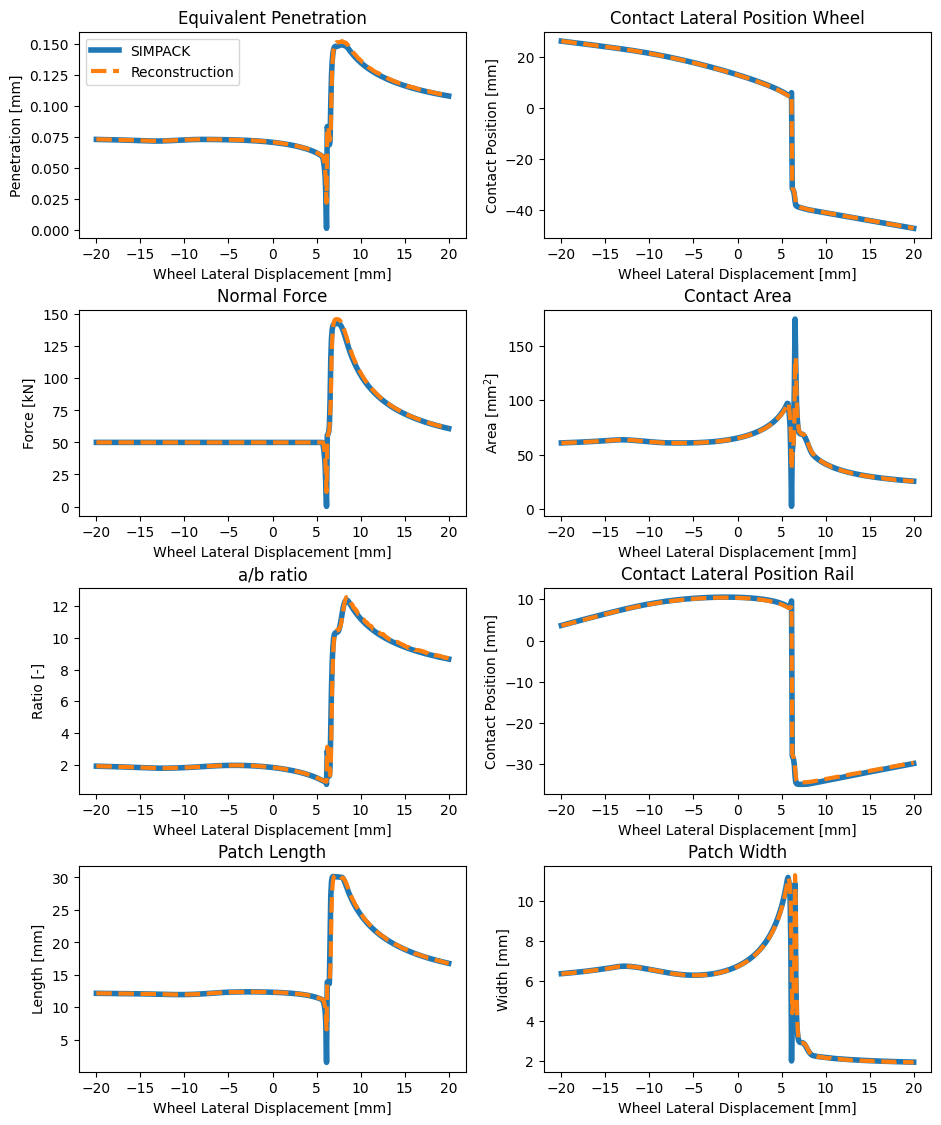

In [107]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize=(11, 13))
fig.subplots_adjust(left=0.125, bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=0.35)

ax[0,0].plot(SIMPACK_EquivalentPenetration[:,0]*10**3, SIMPACK_EquivalentPenetration[:,1]*10**3, linewidth=4.0, label = "SIMPACK")
ax[0,0].plot(deltays*10**3, approaces*10**3, linewidth = 3.0, linestyle='--', label = "Reconstruction")
ax[0,0].set_title('Equivalent Penetration')
ax[0,0].set_xlabel("Wheel Lateral Displacement [mm]")
ax[0,0].set_ylabel("Penetration [mm]")
ax[0,0].legend()

ax[1,0].plot(SIMPACK_NormalForce[:,0]*10**3, SIMPACK_NormalForce[:,1]*10**(-3), linewidth=4.0)
ax[1,0].plot(deltays*10**3, NormalForces*10**(-3), linewidth = 3.0, linestyle='--')
ax[1,0].set_title('Normal Force')
ax[1,0].set_xlabel("Wheel Lateral Displacement [mm]")
ax[1,0].set_ylabel("Force [kN]")

ax[2,0].plot(SIMPACK_SemiAxisRatio[:,0]*10**3, SIMPACK_SemiAxisRatio[:,1], linewidth=4.0)
ax[2,0].plot(deltays*10**3, aHertzs/bHertzs, linewidth = 3.0, linestyle='--')
ax[2,0].set_title('a/b ratio')
ax[2,0].set_xlabel("Wheel Lateral Displacement [mm]")
ax[2,0].set_ylabel("Ratio [-]")

ax[3,0].plot(SIMPACK_PatchLength[:,0]*10**3, SIMPACK_PatchLength[:,1]*10**3, linewidth = 4.0)
ax[3,0].plot(deltays*10**3, 2*aHertzs*10**3, linewidth = 3.0, linestyle='--')
ax[3,0].set_title('Patch Length')
ax[3,0].set_xlabel("Wheel Lateral Displacement [mm]")
ax[3,0].set_ylabel("Length [mm]")

ax[0,1].plot(SIMPACK_ContactLateralPosWheel[:,0]*10**3, SIMPACK_ContactLateralPosWheel[:,1]*10**3, linewidth=4.0)
ax[0,1].plot(deltays*10**3, (Dys-b0)*10**3, linewidth = 3.0, linestyle='--')
ax[0,1].set_title('Contact Lateral Position Wheel')
ax[0,1].set_xlabel("Wheel Lateral Displacement [mm]")
ax[0,1].set_ylabel("Contact Position [mm]")
ax[1,1].plot(SIMPACK_ContactArea[:,0]*10**3, SIMPACK_ContactArea[:,1]*10**6, linewidth=4.0)
ax[1,1].plot(deltays*10**3, aHertzs*bHertzs*np.pi*10**6, linewidth = 3.0, linestyle='--')
ax[1,1].set_title('Contact Area')
ax[1,1].set_xlabel("Wheel Lateral Displacement [mm]")
ax[1,1].set_ylabel("Area [$\mathregular{mm^2}$]")

ax[2,1].plot(SIMPACK_ContactLateralPosRail[:,0]*10**3, SIMPACK_ContactLateralPosRail[:,1]*10**3, linewidth = 4.0)
ax[2,1].plot(deltays*10**3, (DyRails-RailDistance)*10**3, linewidth = 3.0, linestyle='--')
ax[2,1].set_title('Contact Lateral Position Rail')
ax[2,1].set_xlabel("Wheel Lateral Displacement [mm]")
ax[2,1].set_ylabel("Contact Position [mm]")

ax[3,1].plot(SIMPACK_PatchWidth[:,0]*10**3, SIMPACK_PatchWidth[:,1]*10**3, linewidth = 4.0)
ax[3,1].plot(deltays*10**3, 2*bHertzs*10**3, linewidth = 3.0, linestyle='--')
ax[3,1].set_title('Patch Width')
ax[3,1].set_xlabel("Wheel Lateral Displacement [mm]")
ax[3,1].set_ylabel("Width [mm]")

plt.show()